# XGBoost Hyperparameter Optimization
## **Purpose**: Find optimal XGBoost parameters to improve on Random Forest baseline

**Baseline (Random Forest):**
- MAE: €2,031
- R²: 0.794
- Tail Rate: 72.8%

**Goal:** Beat Random Forest performance through gradient boosting

## 1. Setup and Imports

In [19]:
# Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
import json
import os
import time



# Add project root to path
project_root = Path.cwd().parent.parent
sys.path.append(str(project_root))

from src.models.train import (
    load_data,
    split_data_by_marker,
    create_label_encoders,
    apply_encoders
)
from src.evaluation.metrics import (
    calculate_mae,
    calculate_rmse,
    calculate_r2,
    calculate_mape,
    calculate_business_metrics
)

# ML libraries
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV


# Visualization settings
plt.rc('font', size=12)
plt.rc('axes', labelsize=12)
sns.set_style('whitegrid')

print("✅ Setup complete")

✅ Setup complete


## 2. Load and Prepare Data

In [20]:
# Load data (respects data_split markers from preprocessing)
DATA_PATH = "../../data/processed/bmw_pricing_clean.csv"
df_clean, X, y = load_data(DATA_PATH)

# Split data using markers (prevents re-splitting)
X_train, X_val, X_test, y_train, y_val, y_test = split_data_by_marker(df_clean, X, y)

print(f"Train: {X_train.shape}")
print(f"Val:   {X_val.shape}")
print(f"Test:  {X_test.shape}")

INFO:src.models.train:Loading clean dataset from ../../data/processed/bmw_pricing_clean.csv
INFO:src.models.train:✅ Loaded 4,843 rows, 25 features
INFO:src.models.train:Using existing data_split markers from preprocessing
INFO:src.models.train:==================================================
INFO:src.models.train:DATA SPLIT RESULTS
INFO:src.models.train:==================================================
INFO:src.models.train:Training set:     2324 rows (48.0%)
INFO:src.models.train:Validation set:    581 rows (12.0%)
INFO:src.models.train:Test set:          969 rows (20.0%)
INFO:src.models.train:==================================================


Train: (2324, 24)
Val:   (581, 24)
Test:  (969, 24)


## 3. Encode Categorical Features

In [ ]:
# Create encoders from training data ONLY
encoders = create_label_encoders(X_train)

# Apply encoders to all splits
X_train_enc = apply_encoders(X_train, encoders)
X_val_enc = apply_encoders(X_val, encoders)
X_test_enc = apply_encoders(X_test, encoders)

print(f"✅ Encoded {len(encoders)} categorical features")
print(f"Training set shape: {X_train_enc.shape}")

INFO:src.models.train:Creating encoders for: ['maker_key', 'model_key', 'registration_date', 'fuel', 'paint_color', 'car_type', 'sold_at']
INFO:src.models.train:  ✅ maker_key: 1 categories
INFO:src.models.train:  ✅ model_key: 63 categories
INFO:src.models.train:  ✅ registration_date: 177 categories
INFO:src.models.train:  ✅ fuel: 2 categories
INFO:src.models.train:  ✅ paint_color: 7 categories
INFO:src.models.train:  ✅ car_type: 8 categories
INFO:src.models.train:  ✅ sold_at: 9 categories


✅ Encoded 7 categorical features
Training set shape: (2324, 24)


## 4. Baseline XGBoost (Default Parameters)

First, let's establish a baseline with default XGBoost parameters

In [ ]:
# Train baseline XGBoost
baseline_params = {
    'n_estimators': 100,
    'max_depth': 6,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'n_jobs': -1,
    'tree_method': 'hist'
}

print("Training baseline XGBoost...")
baseline_model = xgb.XGBRegressor(**baseline_params)

start_time = time.time()
baseline_model.fit(X_train_enc, y_train)
baseline_time = time.time() - start_time

# Evaluate
y_val_pred_baseline = baseline_model.predict(X_val_enc)
baseline_mae = calculate_mae(y_val, y_val_pred_baseline)
baseline_r2 = calculate_r2(y_val, y_val_pred_baseline)
baseline_business = calculate_business_metrics(y_val, y_val_pred_baseline)

print(f"\n📊 Baseline XGBoost Performance:")
print(f"  MAE:    €{baseline_mae:,.0f}")
print(f"  R²:     {baseline_r2:.3f}")
print(f"  TR:     {baseline_business['tail_rate']:.1f}%")
print(f"  TC-APE: {baseline_business['tc_ape']:.1f}%")
print(f"  Time:   {baseline_time:.1f}s")

Training baseline XGBoost...

📊 Baseline XGBoost Performance:
  MAE:    €1,989
  R²:     0.751
  TR:     69.2%
  TC-APE: 25.2%
  Time:   0.2s


## 5. Hyperparameter Tuning with RandomizedSearchCV

**Strategy:** Use randomized search to explore hyperparameter space efficiently

**Key XGBoost Parameters:**
- `n_estimators`: Number of boosting rounds
- `max_depth`: Maximum tree depth (controls overfitting)
- `learning_rate`: Step size shrinkage (lower = more conservative)
- `subsample`: Fraction of samples for each tree
- `colsample_bytree`: Fraction of features for each tree
- `gamma`: Minimum loss reduction for split
- `reg_alpha`: L1 regularization
- `reg_lambda`: L2 regularization

In [23]:
# Define parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5, 1.0],
    'reg_alpha': [0, 0.01, 0.1, 1, 10],
    'reg_lambda': [1, 1.5, 2, 5, 10],
    'min_child_weight': [1, 3, 5, 7]
}

# Initialize base model
xgb_base = xgb.XGBRegressor(
    random_state=42,
    n_jobs=1,
    tree_method='hist'
)

# Random search
random_search = RandomizedSearchCV(
    xgb_base,
    param_distributions=param_dist,
    n_iter=30,              # Try 30 random combinations
    cv=3,                   # 3-fold cross-validation
    scoring='r2',           # Optimize for R²
    n_jobs=1,
    random_state=42,
    verbose=2
)

print("🔍 Running Randomized Search (this may take 5-10 minutes)...")
print("Testing 30 parameter combinations with 3-fold CV...\n")

search_start = time.time()
random_search.fit(X_train_enc, y_train)
search_time = time.time() - search_start

# Best model found
best_model = random_search.best_estimator_
best_params = random_search.best_params_

print(f"\n✅ Search completed in {search_time/60:.1f} minutes")
print(f"\n✅ Best parameters found:")
for param, value in best_params.items():
    print(f"  {param:20s}: {value}")
print(f"\n✅ Best CV R²: {random_search.best_score_:.3f}")

🔍 Running Randomized Search (this may take 5-10 minutes)...
Testing 30 parameter combinations with 3-fold CV...

Fitting 3 folds for each of 30 candidates, totalling 90 fits
[CV] END colsample_bytree=0.6, gamma=0.2, learning_rate=0.1, max_depth=3, min_child_weight=7, n_estimators=500, reg_alpha=1, reg_lambda=1.5, subsample=0.9; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0.2, learning_rate=0.1, max_depth=3, min_child_weight=7, n_estimators=500, reg_alpha=1, reg_lambda=1.5, subsample=0.9; total time=   0.2s
[CV] END colsample_bytree=0.6, gamma=0.2, learning_rate=0.1, max_depth=3, min_child_weight=7, n_estimators=500, reg_alpha=1, reg_lambda=1.5, subsample=0.9; total time=   0.2s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.2, max_depth=8, min_child_weight=5, n_estimators=200, reg_alpha=0.01, reg_lambda=1.5, subsample=0.6; total time=   0.1s
[CV] END colsample_bytree=0.8, gamma=0.5, learning_rate=0.2, max_depth=8, min_child_weight=5, n_estimators=200, reg_alpha=0

## 6. Save Best Parameters

In [ ]:
# Save to config directory
project_root = Path.cwd().parent.parent
config_path = project_root / "config" / "models" / "best_xgboost_params.json"

# Create directory if needed
config_path.parent.mkdir(parents=True, exist_ok=True)

# Add required parameters
best_params['n_jobs'] = -1
best_params['random_state'] = 42
best_params['tree_method'] = 'hist'
best_params['objective'] = 'reg:squarederror'

# Save params
with open(config_path, 'w') as f:
    json.dump(best_params, f, indent=2)

print(f"✅ Best params saved to: {config_path}")
print(f"\n📄 Contents:")
print(json.dumps(best_params, indent=2))

✅ Best params saved to: /Users/Mac/GoogleMLEngineerCertification/PHASE-1/bmw-pricing-challenger/config/models/best_xgboost_params.json

📄 Contents:
{
  "subsample": 0.9,
  "reg_lambda": 5,
  "reg_alpha": 0,
  "n_estimators": 300,
  "min_child_weight": 1,
  "max_depth": 4,
  "learning_rate": 0.05,
  "gamma": 0.2,
  "colsample_bytree": 0.6,
  "n_jobs": 1,
  "random_state": 42,
  "tree_method": "hist",
  "objective": "reg:squarederror"
}


## 7. Evaluate Best Model on Validation Set

In [25]:
# Make predictions on validation set
y_val_pred = best_model.predict(X_val_enc)

# Calculate all metrics
mae = calculate_mae(y_val, y_val_pred)
rmse = calculate_rmse(y_val, y_val_pred)
r2 = calculate_r2(y_val, y_val_pred)
mape = calculate_mape(y_val, y_val_pred)
business_metrics = calculate_business_metrics(y_val, y_val_pred)

print(f"📊 Optimized XGBoost Performance:")
print(f"="*50)
print(f"  MAE:    €{mae:,.0f}")
print(f"  RMSE:   €{rmse:,.0f}")
print(f"  R²:     {r2:.3f}")
print(f"  MAPE:   {mape:.1f}%")
print(f"  TR:     {business_metrics['tail_rate']:.1f}%")
print(f"  TC-APE: {business_metrics['tc_ape']:.1f}%")
print(f"="*50)

# Check targets
print(f"\n🎯 Target Comparison:")
print(f"  MAE < €2,500:     {'✅' if mae < 2500 else '❌'}")
print(f"  RMSE < €3,000:    {'✅' if rmse < 3000 else '❌'}")
print(f"  R² > 0.85:        {'✅' if r2 > 0.85 else '❌'}")
print(f"  MAPE < 4.5%:      {'✅' if mape < 4.5 else '❌'}")
print(f"  TR < 15%:         {'✅' if business_metrics['tail_rate'] < 15 else '❌'}")
print(f"  TC-APE < 6.5%:    {'✅' if business_metrics['tc_ape'] < 6.5 else '❌'}")

📊 Optimized XGBoost Performance:
  MAE:    €1,981
  RMSE:   €3,044
  R²:     0.765
  MAPE:   18.0%
  TR:     67.6%
  TC-APE: 25.5%

🎯 Target Comparison:
  MAE < €2,500:     ✅
  RMSE < €3,000:    ❌
  R² > 0.85:        ❌
  MAPE < 4.5%:      ❌
  TR < 15%:         ❌
  TC-APE < 6.5%:    ❌


## 8. Compare Against Baseline

In [26]:
# Calculate improvements
mae_improvement = ((baseline_mae - mae) / baseline_mae) * 100
r2_improvement = ((r2 - baseline_r2) / baseline_r2) * 100
tr_improvement = ((baseline_business['tail_rate'] - business_metrics['tail_rate']) / baseline_business['tail_rate']) * 100

print("\n" + "="*50)
print("IMPROVEMENT vs BASELINE")
print("="*50)
print(f"  MAE:       {mae_improvement:+.1f}% {'✅' if mae_improvement > 0 else '❌'}")
print(f"  R²:        {r2_improvement:+.1f}% {'✅' if r2_improvement > 0 else '❌'}")
print(f"  Tail Rate: {tr_improvement:+.1f}% {'✅' if tr_improvement > 0 else '❌'}")
print("="*50)

if mae_improvement > 0 and r2_improvement > 0:
    print("\n🎉 Optimized XGBoost beats baseline!")
else:
    print("\n⚠️  Baseline is competitive - consider ensemble")


IMPROVEMENT vs BASELINE
  MAE:       +0.4% ✅
  R²:        +1.9% ✅
  Tail Rate: +2.2% ✅

🎉 Optimized XGBoost beats baseline!


## 9. Feature Importance Analysis


🔝 Top 15 Features by Importance:
  registration_date         0.1273
  car_age_years             0.1201
  engine_power              0.0893
  mileage_per_power         0.0870
  feature_4                 0.0837
  is_price_outlier          0.0604
  model_key                 0.0591
  feature_8                 0.0589
  feature_5                 0.0514
  feature_2                 0.0452
  age_mileage_interaction   0.0311
  feature_1                 0.0295
  mileage                   0.0277
  feature_7                 0.0240
  annual_mileage            0.0231


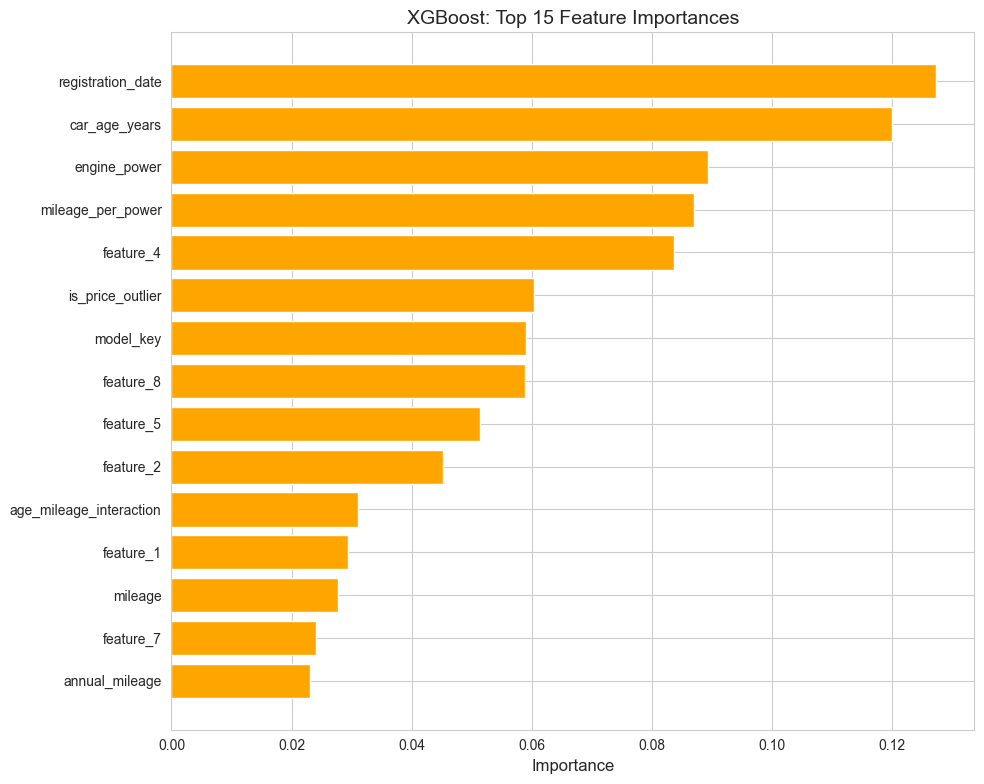

In [27]:
# Get feature importance
importances = best_model.feature_importances_
feature_names = X_train_enc.columns.tolist()

# Create importance dataframe
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Display top 15
print("\n🔝 Top 15 Features by Importance:")
print("="*50)
for i, row in feature_importance_df.head(15).iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.4f}")

# Plot
plt.figure(figsize=(10, 8))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['importance'], color='orange')
plt.yticks(range(len(top_features)), top_features['feature'])
plt.xlabel('Importance')
plt.title('XGBoost: Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 10. Cross-Validation Results Analysis

In [28]:
# Get CV results
cv_results = pd.DataFrame(random_search.cv_results_)

# Sort by test score
cv_results_sorted = cv_results.sort_values('rank_test_score')

# Display top 10 parameter combinations
print("\n📊 Top 10 Parameter Combinations:")
print("="*80)

for idx, row in cv_results_sorted.head(10).iterrows():
    print(f"\nRank {int(row['rank_test_score'])}:")
    print(f"  Mean CV R²: {row['mean_test_score']:.4f} (+/- {row['std_test_score']:.4f})")
    print(f"  Params: {row['params']}")


📊 Top 10 Parameter Combinations:

Rank 1:
  Mean CV R²: 0.7422 (+/- 0.0182)
  Params: {'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.05, 'gamma': 0.2, 'colsample_bytree': 0.6, 'n_jobs': 1, 'random_state': 42, 'tree_method': 'hist', 'objective': 'reg:squarederror'}

Rank 2:
  Mean CV R²: 0.7408 (+/- 0.0224)
  Params: {'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.2, 'gamma': 0.1, 'colsample_bytree': 0.7}

Rank 3:
  Mean CV R²: 0.7368 (+/- 0.0180)
  Params: {'subsample': 0.7, 'reg_lambda': 1, 'reg_alpha': 1, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.9}

Rank 4:
  Mean CV R²: 0.7363 (+/- 0.0179)
  Params: {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.05, 'ga

## 11. Learning Curve Analysis

Visualize how performance improves with more boosting rounds

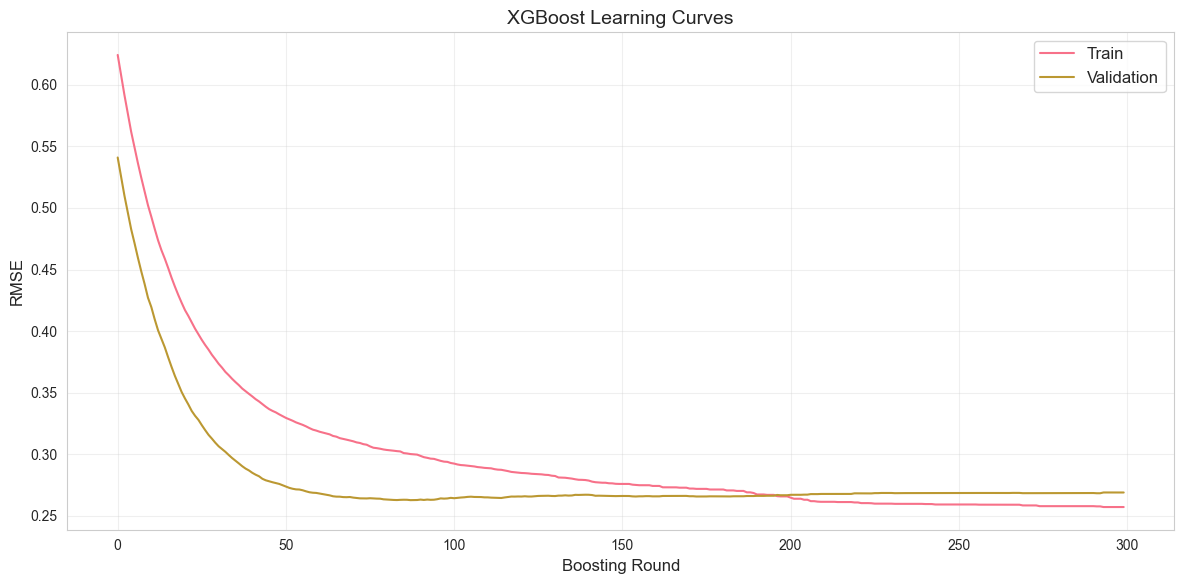


Optimal number of rounds: 87


In [29]:
# Train model with eval_set to track performance
eval_model = xgb.XGBRegressor(**best_params)
eval_model.fit(
    X_train_enc, y_train,
    eval_set=[(X_train_enc, y_train), (X_val_enc, y_val)],
    verbose=False
)

# Get eval results
results = eval_model.evals_result()

# Plot learning curves
fig, ax = plt.subplots(figsize=(12, 6))

epochs = len(results['validation_0']['rmse'])
x_axis = range(0, epochs)

ax.plot(x_axis, results['validation_0']['rmse'], label='Train')
ax.plot(x_axis, results['validation_1']['rmse'], label='Validation')
ax.legend()
ax.set_ylabel('RMSE')
ax.set_xlabel('Boosting Round')
ax.set_title('XGBoost Learning Curves')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimal number of rounds: {np.argmin(results['validation_1']['rmse'])}")

## 12. Summary and Next Steps

In [30]:
print("\n" + "="*80)
print("✅ XGBOOST HYPERPARAMETER TUNING COMPLETE")
print("="*80)

print(f"\n📁 Best parameters saved to:")
print(f"   {config_path}")

print(f"\n📊 Best validation metrics:")
print(f"   MAE:  €{mae:,.0f}")
print(f"   R²:   {r2:.3f}")
print(f"   TR:   {business_metrics['tail_rate']:.1f}%")

print(f"\n🚀 Next steps:")
print(f"   1. Review the best parameters above")
print(f"   2. Run comparison: python scripts/training/compare_models.py")
print(f"   3. Or train directly: from src.models.xgboost_trainer import train_xgboost_model")
print(f"   4. If satisfied, move to deployment (Iteration 3+)")

all_targets_met = (
    mae < 2500 and
    rmse < 3000 and
    r2 > 0.85 and
    mape < 4.5 and
    business_metrics['tail_rate'] < 15 and
    business_metrics['tc_ape'] < 6.5
)

if all_targets_met:
    print(f"\n🎉 All business targets met! Ready for production.")
else:
    print(f"\n⚠️  Some targets not met. Recommendations:")
    if business_metrics['tail_rate'] > 15:
        print(f"   - Tail rate still high ({business_metrics['tail_rate']:.1f}%)")
        print(f"   - Consider: (1) More granular features (2) Ensemble methods")
    if r2 < 0.85:
        print(f"   - R² below target ({r2:.3f})")
        print(f"   - Consider: (1) Feature engineering (2) Polynomial features")


✅ XGBOOST HYPERPARAMETER TUNING COMPLETE

📁 Best parameters saved to:
   /Users/Mac/GoogleMLEngineerCertification/PHASE-1/bmw-pricing-challenger/config/models/best_xgboost_params.json

📊 Best validation metrics:
   MAE:  €1,981
   R²:   0.765
   TR:   67.6%

🚀 Next steps:
   1. Review the best parameters above
   2. Run comparison: python scripts/training/compare_models.py
   3. Or train directly: from src.models.xgboost_trainer import train_xgboost_model
   4. If satisfied, move to deployment (Iteration 3+)

⚠️  Some targets not met. Recommendations:
   - Tail rate still high (67.6%)
   - Consider: (1) More granular features (2) Ensemble methods
   - R² below target (0.765)
   - Consider: (1) Feature engineering (2) Polynomial features
